In [466]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
plt.rcParams["figure.figsize"] = (5,3)
# Getting the data
seattle_url = "https://assets.datacamp.com/production/repositories/3634/datasets/6fd451508ecce0d63354fad86704236592eed8ca/seattle_weather.csv"
austin_url = "https://assets.datacamp.com/production/repositories/3634/datasets/e76b460b41dc7ff286d78246daf3a8c324cb5587/austin_weather.csv"
df1 = pd.read_csv(seattle_url)
df2 = pd.read_csv(austin_url)
seattle = df1.copy()
austin = df2.copy()
seattle_weather = seattle.iloc[0:12, :] # Subset
austin_weather = austin.iloc[0:12, :] # Subset

In [467]:
# Change the numerical Month column to a factor Month column
seattle_weather['DATE'] = seattle_weather['DATE'].astype('category')
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
seattle_weather['DATE'] = seattle_weather['DATE'].map(month_map)
seattle_weather.rename(columns={'DATE':'MONTH'}, inplace= True)
seattle_weather.head()

,STATION,NAME,MONTH,MLY-CLDD-BASE45,MLY-CLDD-BASE50,MLY-CLDD-BASE55,MLY-CLDD-BASE57,MLY-CLDD-BASE60,MLY-CLDD-BASE70,MLY-CLDD-BASE72,...,MLY-TMIN-AVGNDS-LSTH060,MLY-TMIN-AVGNDS-LSTH070,MLY-TMIN-NORMAL,MLY-TMIN-PRBOCC-LSTH016,MLY-TMIN-PRBOCC-LSTH020,MLY-TMIN-PRBOCC-LSTH024,MLY-TMIN-PRBOCC-LSTH028,MLY-TMIN-PRBOCC-LSTH032,MLY-TMIN-PRBOCC-LSTH036,MLY-TMIN-STDDEV
0,USC00456295,"PALMER 3 ESE, WA US",Jan,13.0,1.0,-7777.0,0.0,0.0,0.0,0.0,...,310.0,310.0,34.0,168.0,327.0,615.0,877.0,987.0,1000.0,2.8
1,USC00456295,"PALMER 3 ESE, WA US",Feb,23.0,3.0,-7777.0,-7777.0,0.0,0.0,0.0,...,280.0,280.0,33.9,132.0,275.0,515.0,800.0,963.0,1000.0,3.1
2,USC00456295,"PALMER 3 ESE, WA US",Mar,50.0,11.0,1.0,-7777.0,-7777.0,0.0,0.0,...,310.0,310.0,35.9,5.0,47.0,111.0,393.0,848.0,1000.0,2.1
3,USC00456295,"PALMER 3 ESE, WA US",Apr,108.0,40.0,12.0,7.0,3.0,-7777.0,0.0,...,300.0,300.0,38.3,0.0,0.0,5.0,123.0,571.0,978.0,2.0
4,USC00456295,"PALMER 3 ESE, WA US",May,255.0,130.0,56.0,38.0,19.0,1.0,-7777.0,...,310.0,310.0,43.5,0.0,0.0,0.0,0.0,83.0,610.0,2.0


In [468]:
# Same for austin dataset
austin_weather['DATE'] = austin_weather['DATE'].astype('category').map(month_map)
austin_weather.rename(columns={'DATE':'MONTH'}, inplace= True)
austin_weather.head()

,STATION,NAME,MONTH,MLY-CLDD-BASE45,MLY-CLDD-BASE50,MLY-CLDD-BASE55,MLY-CLDD-BASE57,MLY-CLDD-BASE60,MLY-CLDD-BASE70,MLY-CLDD-BASE72,...,MLY-TMIN-AVGNDS-LSTH060,MLY-TMIN-AVGNDS-LSTH070,MLY-TMIN-NORMAL,MLY-TMIN-PRBOCC-LSTH016,MLY-TMIN-PRBOCC-LSTH020,MLY-TMIN-PRBOCC-LSTH024,MLY-TMIN-PRBOCC-LSTH028,MLY-TMIN-PRBOCC-LSTH032,MLY-TMIN-PRBOCC-LSTH036,MLY-TMIN-STDDEV
0,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Jan,190,103,50,35,18,1,-7777,...,302,310,36.3,298,570,839,967,997,1000,2.9
1,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Feb,228,132,68,49,29,3,1,...,264,280,39.4,103,327,614,867,973,999,3.2
2,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Mar,446,306,185,146,98,13,6,...,270,308,46.6,10,73,242,494,761,928,3.6
3,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",Apr,668,519,373,318,240,53,32,...,193,287,54.7,0,0,0,48,189,453,4.1
4,USW00013904,"AUSTIN BERGSTROM INTERNATIONAL AIRPORT, TX US",May,936,781,626,564,471,181,134,...,89,250,63.7,0,0,0,0,0,0,2.5


# 1. Data Visualisation with Matplotlib

## 1.1 Interface

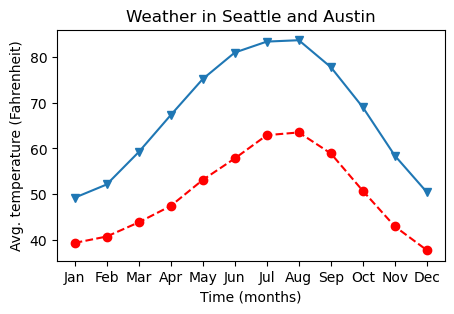

In [469]:
fig, ax = plt.subplots() # Setup the pyplot interface
ax.plot(seattle_weather["MONTH"], seattle_weather['MLY-TAVG-NORMAL'], marker = 'o', 
        linestyle = '--', color = 'r')
ax.plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"], marker = 'v')
ax.set_xlabel("Time (months)")
ax.set_ylabel("Avg. temperature (Fahrenheit)")
ax.set_title("Weather in Seattle and Austin")
plt.show()

## 1.2 Subplots

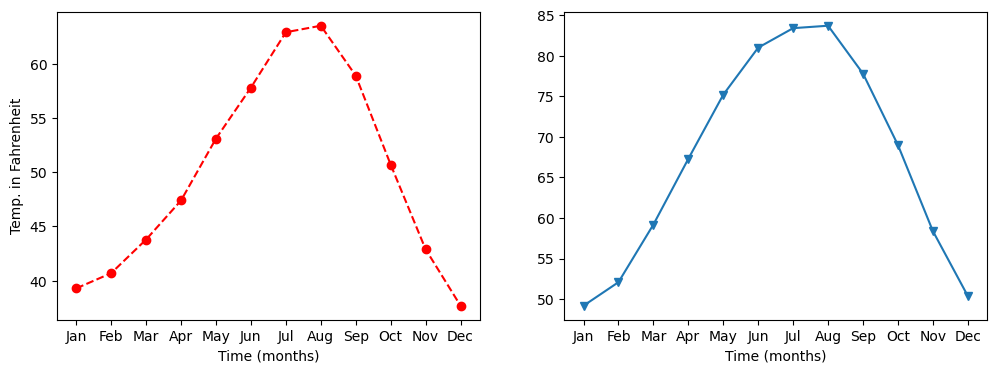

In [470]:
fig, ax = plt.subplots(1,2, figsize = (12,4), sharex=True)
ax[0].plot(seattle_weather["MONTH"], seattle_weather['MLY-TAVG-NORMAL'], marker = 'o', 
        linestyle = '--', color = 'r')
ax[1].plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"], marker = 'v')
ax[0].set_xlabel("Time (months)")
ax[1].set_xlabel("Time (months)")
ax[0].set_ylabel("Temp. in Fahrenheit")
plt.show()

### 1.3 Time-series data

In [471]:
# Load the data and choose 'date' as the index (as date format)
climate_url = "https://assets.datacamp.com/production/repositories/3634/datasets/411add3f8570d5adf891127fd64095020210711b/climate_change.csv"
climate_change = pd.read_csv(climate_url, parse_dates=['date'], index_col='date')
climate_change.head()

,co2,relative_temp
date,,
1958-03-06,315.71,0.10
1958-04-06,317.45,0.01
1958-05-06,317.50,0.08
1958-06-06,NaN,-0.05
1958-07-06,315.86,0.06


In [472]:
# Reusable plotting function
def plot_timeseries(axes, x, y, color, xlabel, ylabel):
    axes.plot(x, y, color = color)
    axes.tick_params('y', colors = color)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)

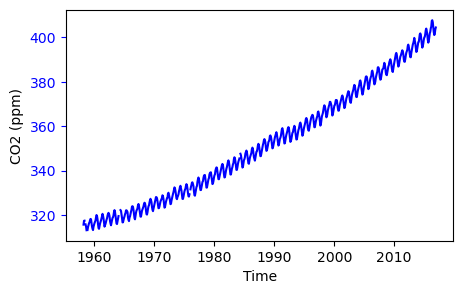

In [473]:
# Plot the data
fig, ax = plt.subplots()
plot_timeseries(ax, climate_change.index, climate_change['co2'], 'blue', 'Time', 'CO2 (ppm)')
plt.show()

#### Text Annotation

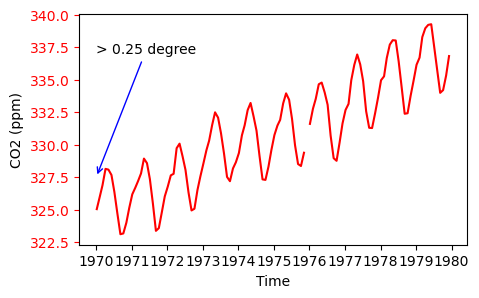

In [474]:
# Zooming in
seventies = climate_change['1970-01-01':"1979-12-31"]
fig, ax = plt.subplots()
plot_timeseries(ax, seventies.index, seventies['co2'], 'red', 'Time', 'CO2 (ppm)')
ax.annotate("> 0.25 degree",
            xy = (pd.Timestamp('1970-01-01'), 327.5),
            xytext=(pd.Timestamp('1970-01-01'), 337),
            arrowprops={"arrowstyle":"->", "color":"blue"})
plt.show()

## 1.3 Quantitative comparisons

### 1.3.1 Bar-charts
Quantitative comparisons between categories.

In [475]:
# Get data
medals_url = "https://assets.datacamp.com/production/repositories/3634/datasets/ec663f9f509bf633d40932f65bd4cc51205689e2/medals_by_country_2016.csv"
medals = pd.read_csv(medals_url, index_col=0)
medals.head()

,Bronze,Gold,Silver
United States,67,137,52
Germany,67,47,43
Great Britain,26,64,55
Russia,35,50,28
China,35,44,30


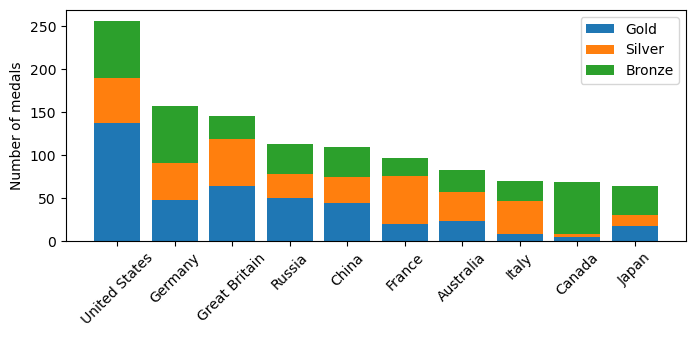

In [476]:
# Visualising the bar chart
fig, ax = plt.subplots(figsize = (8,3))
ax.bar(medals.index, medals['Gold'], label = "Gold")
ax.bar(medals.index, medals['Silver'], bottom=medals['Gold'], label = "Silver")
ax.bar(medals.index, medals['Bronze'], bottom=medals['Gold'] + medals['Silver'], 
       label = "Bronze")
plt.setp(ax.get_xticklabels(), rotation = 45) # Rotate the ticklabels by 45 degrees
ax.set_ylabel("Number of medals")
plt.legend()
plt.show()

### 1.3.2 Histograms
Quantitative comparisons within variable bins.

In [477]:
# Get the data
url = "https://assets.datacamp.com/production/repositories/3634/datasets/67d7344085ace400d612275b87738615698127a3/summer2016.csv"
data = pd.read_csv(url, index_col=0)
mens_rowing = data[(data['Sport'] == "Rowing")&(data['Sex'] == 'M')]
mens_gymnastics = data[(data['Sport'] == "Gymnastics")&(data['Sex'] == 'M')]

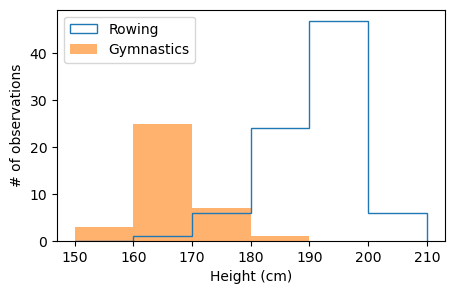

In [478]:
# Visualise histogram
fig, ax = plt.subplots()
ax.hist(mens_rowing['Height'], label = "Rowing", bins = np.linspace(150,210,7), histtype = 'step')
ax.hist(mens_gymnastics['Height'], label = "Gymnastics", bins = np.linspace(150,210,7), alpha = 0.6)
ax.set_xlabel("Height (cm)")
ax.set_ylabel("# of observations")
ax.legend()
plt.show()

### 1.3.3 Boxplot
Used to compare a quantitative variable across qualitative groups.

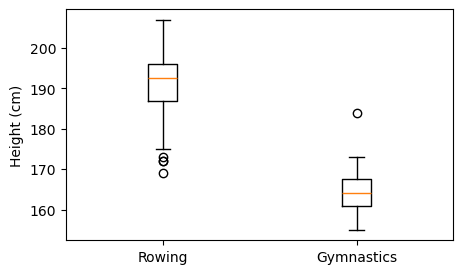

In [479]:
fig, ax = plt.subplots()
ax.boxplot([mens_rowing['Height'], mens_gymnastics['Height']])
ax.set_xticklabels(["Rowing", "Gymnastics"])
ax.set_ylabel("Height (cm)")
plt.show()

### 1.3.4 Scatterplot
Used to explore correlation or relationships of two numeric variables. We include color for the comparison of a third variable.

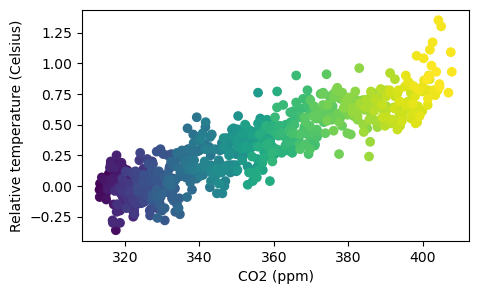

In [480]:
fig, ax = plt.subplots()
ax.scatter(climate_change['co2'], climate_change['relative_temp'], c = climate_change.index)
ax.set_xlabel("CO2 (ppm)")
ax.set_ylabel("Relative temperature (Celsius)")
plt.show()

## 1.4 Plot style
- *plt.style.use("ggplot")*
- *plt.style.use("default")*
- *plt.style.use("bmh")*
- *plt.style.use("seaborn-colorblind")*

## 1.5 Sharing figures
- *fig.savefig(name.png, dpi = 300)*
- *fig.savefig(name.jpg, quality = 50)*
- *fig.savefig(name.svg)*

## 1.6 Other Aesthetics
- *fig.set_size_inches([5, 3]])*

# 2. Seaborn
- Useful in the Explore and Communicate Results phase

In [481]:
# Get the data
cars_url = "https://assets.datacamp.com/production/repositories/3996/datasets/e0b285b89bdbfbbe8d81123e64727ff150d544e0/mpg.csv"
cars = pd.read_csv(cars_url)
cars['cylinders'] = cars['cylinders'].astype("category")
cars['cylinders'] = cars['cylinders'].replace({3:4, 5:6})
cars.head()

/var/folders/bh/_p1bkhtn09b6syd7vz5f61pw0000gn/T/ipykernel_24919/3274827243.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cars['cylinders'] = cars['cylinders'].replace({3:4, 5:6})


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 2.1 Using DataFrames with *countplot()*

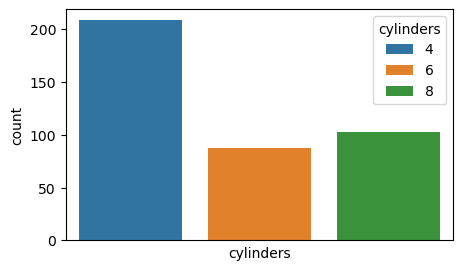

In [482]:
# Visualise the data
sns.countplot(x = "cylinders", data = cars, hue = "cylinders")
plt.xticks([]) # Turn x-axis off
plt.show()

## 2.2 Scatterplot in Seaborn

<Axes: xlabel='horsepower', ylabel='mpg'>

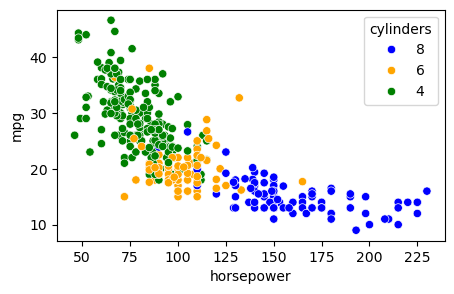

In [483]:
# Simple scatterplot
hue_colors = {8: "blue", 6: "orange", 4: "green"}
sns.scatterplot(x = "horsepower", y = "mpg", data = cars,
                hue = "cylinders", hue_order=[8, 6, 4],
                palette=hue_colors)

## 2.3 Relational plots using _relplot()_
- Creates "relational plots": scatter plots or line plots
- _relplot()_ lets you create subplots in a single figure

### 2.3.1 Scatterplot using *relplot()*

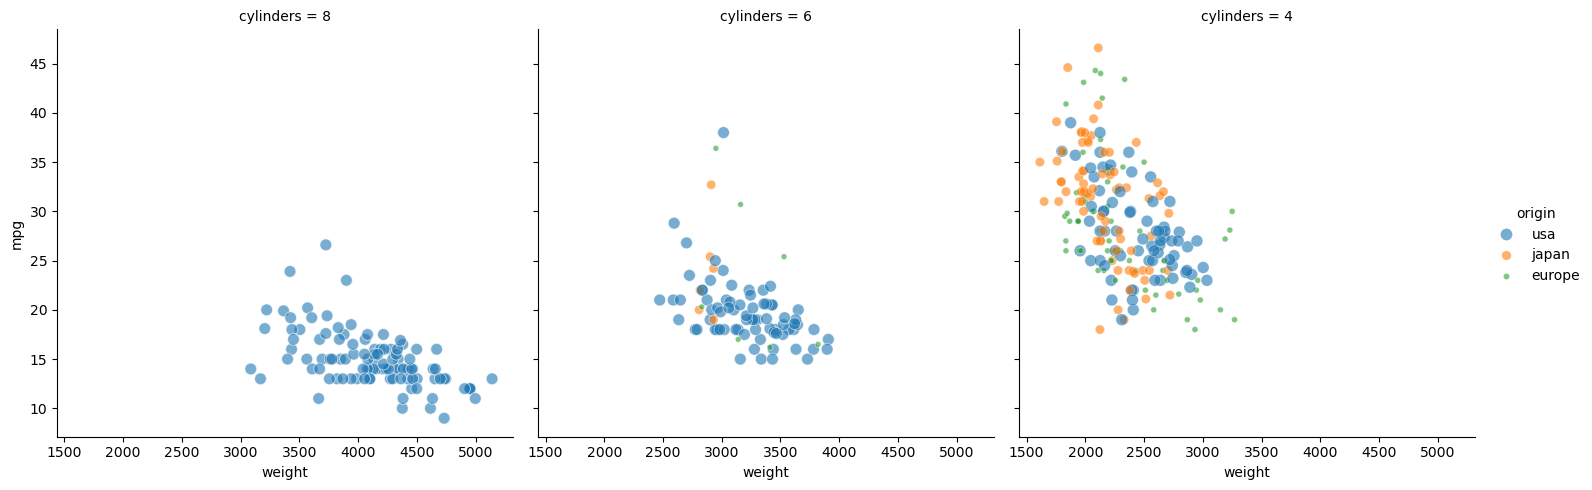

In [484]:
# Using relplot
sns.relplot(x = "weight", y = "mpg", data = cars,
            kind = "scatter", col = "cylinders", col_order=[8, 6, 4],
            hue = "origin", size = 'origin', alpha = 0.6) # 'row' or both also possible
plt.show()

### 2.3.2 Lineplots using *relplot()*

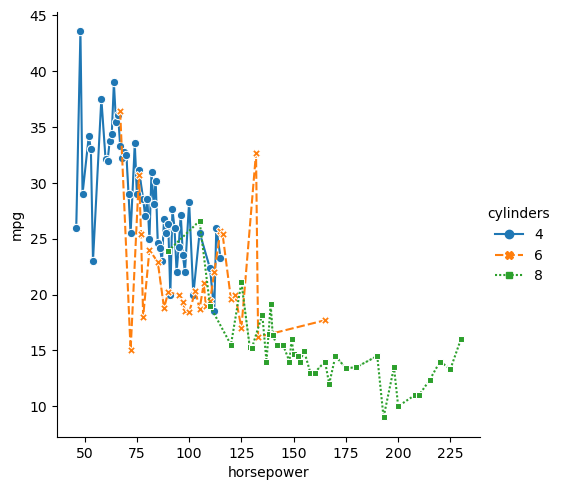

In [485]:
sns.relplot(x = "horsepower", y = "mpg", data = cars,
            kind = 'line', errorbar = ('ci', False), style = 'cylinders', hue = 'cylinders', markers = True)
plt.show()

## 2.4 Categorical plots using *catplot()*

### 2.4.1 Countplot

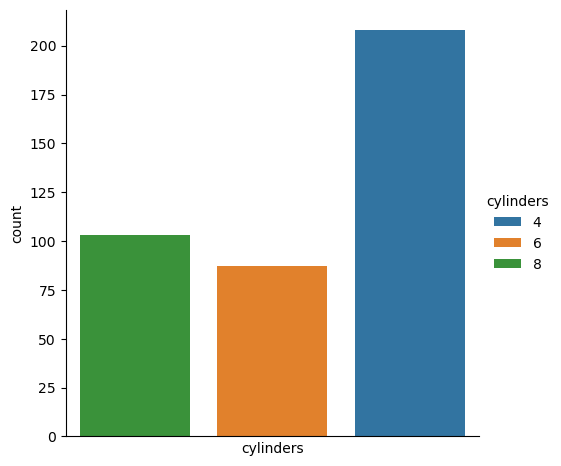

In [486]:
sns.catplot(x = 'cylinders', data = cars,
            kind = 'count', order = [8, 6, 4], hue = "cylinders")
plt.xticks([])
plt.show()

### 2.4.2 Barplot
- Lines show 95% of confidence intervals for the mean
- Shows uncertainty about our estimate

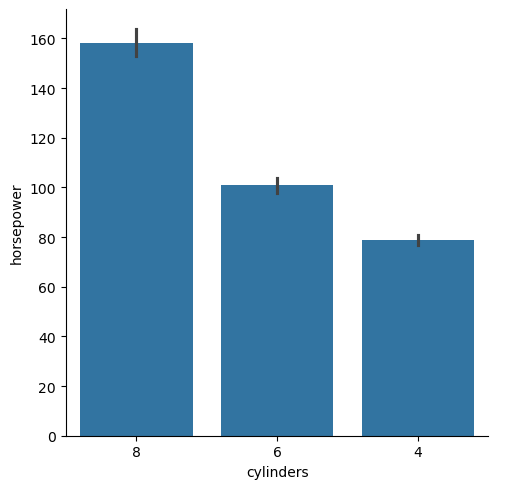

In [487]:
sns.catplot(x = 'cylinders', y = 'horsepower',data = cars,
            kind = 'bar', order = [8, 6, 4], errorbar=("ci",95))
plt.show()

### 2.4.3 Boxlplot
- Shows distribution of quantiative data
- See median, spread, skewness, and outliers
- Facilitates comparisons between groups
- _whis_ = shows the 5th and 95th percentiles

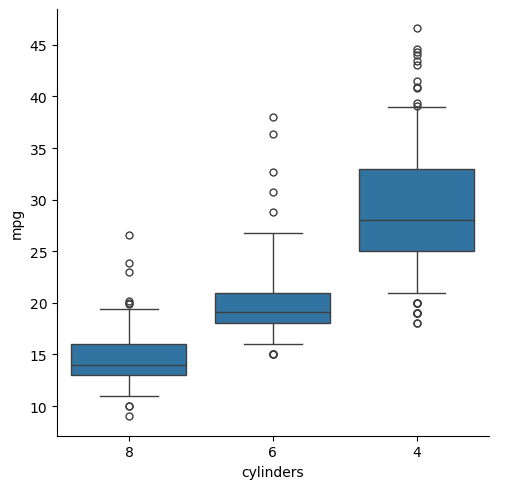

In [488]:
sns.catplot(x = 'cylinders', y = 'mpg', data = cars,
            kind = 'box', order = [8,6,4], whis = [5,95])
plt.show()

### 2.4.4 Point plot
- Point plot has categorical variable on x-axis
- Shows mean of quantitative variable and 95% confidence intervals for mean

In [489]:
# Prepare the dataset
medals_reset = medals.reset_index().rename(columns={"index":"Country"}).sort_values("Country")
melted_medals  = medals_reset.melt(id_vars="Country", value_name="Count", var_name="Medal")

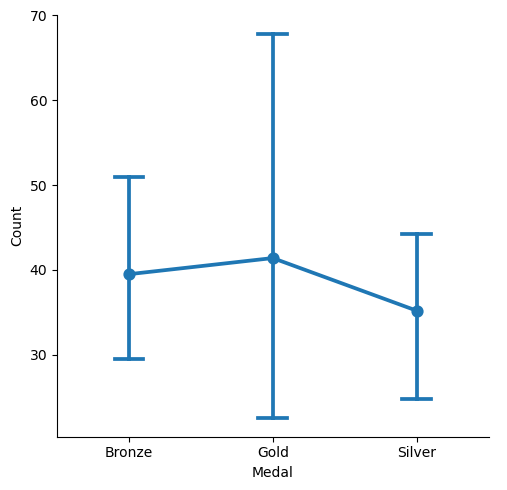

In [490]:
# Point plot
sns.catplot(x = 'Medal', y = 'Count', data = melted_medals,
            kind = 'point', capsize = 0.2)
plt.show()

## 2.5 Adding titles and labels

### 2.5.1 Adding it to FacetGrid
Can create subplots. Contains:
- replot()
- catplot()

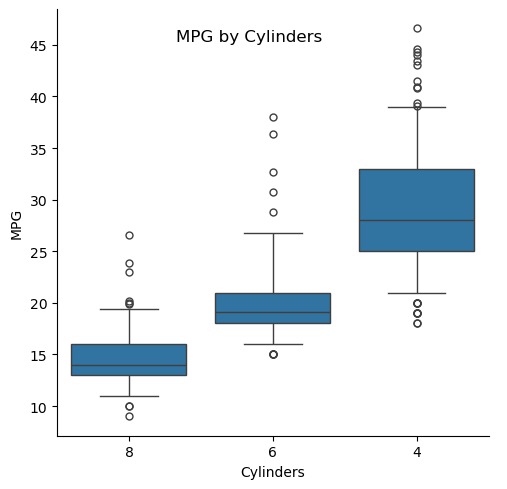

In [491]:
g = sns.catplot(x = 'cylinders', y = 'mpg', data = cars,
            kind = 'box', order = [8,6,4], whis = [5,95])
g.fig.suptitle("MPG by Cylinders", y = 0.93)
g.set(xlabel="Cylinders")
g.set(ylabel="MPG")
plt.show()

### 2.5.2 Adding it to AxesSubplot
Can only create a single plot. Contains:
- scatterplot()
- countplot()
- etc.

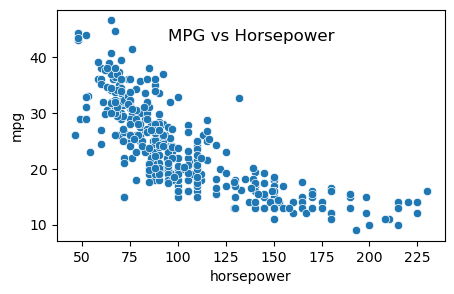

In [492]:
h = sns.scatterplot(x = 'horsepower', y = 'mpg', data = cars)
h.set_title("MPG vs Horsepower", y = 0.83)
plt.show()

## 2.6 Change plot style
- *sns.set_style()*
- Preset options: "white", "dark", "whitegrid", "darkgrid", "ticks"

### 2.6.1 Changing the palette
- *sns.set_palette*
- Diverging palettes: "RdBu", "Greys", "Blues", "PuRd", "GnBu"

### 2.6.2 Changing the scale
*sns.set_context()*
- Smallest to largest: "paper", "notebook", "talk", "poster"

## 3. Statistical plotting

### 3.1 Pairplot
Quick overview of the relationship of all features to each other.

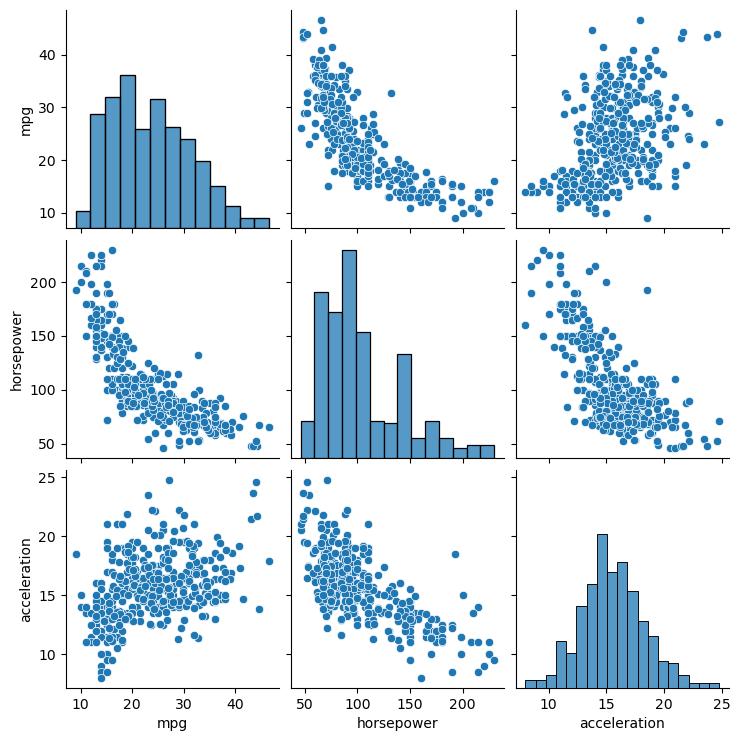

In [500]:
# sns.pairplot(cars)
sns.pairplot(cars, vars = ['mpg', 'horsepower', 'acceleration'])
plt.show()